
Run with step size h = 0.1
x		Error(current run vs first run)
0.00		0.00000000
0.10		0.00000000
0.20		0.00000000
0.30		0.00000000
0.40		0.00000000
0.50		0.00000000
0.60		0.00000000
0.70		0.00000000
0.80		0.00000000
0.90		0.00000000
1.00		0.00000000
1.10		0.00000000
1.20		0.00000000
1.30		0.00000000
1.40		0.00000000
1.50		0.00000000
1.60		0.00000000
1.70		0.00000000
1.80		0.00000000
1.90		0.00000000
2.00		0.00000000
Local errors: [0.01873075 0.01533544 0.0125556  0.01027966 0.00841627 0.00689066
 0.00564159 0.00461895 0.00378167 0.00309617 0.00253493 0.00207543
 0.00169922 0.0013912  0.00113902 0.00093255 0.00076351 0.00062511
 0.00051179 0.00041902]
Global errors: [0.         0.01873075 0.03032005 0.03681164 0.03972896 0.04019944
 0.03905021 0.03688176 0.03412436 0.03108116 0.0279611  0.02490381
 0.02199848 0.019298   0.0168296  0.0146027  0.01261471 0.01085527
 0.00930932 0.00795925 0.00678642]
Total local error = 0.10143854
Total global error = 0.48004699
Total accumulated error vs 

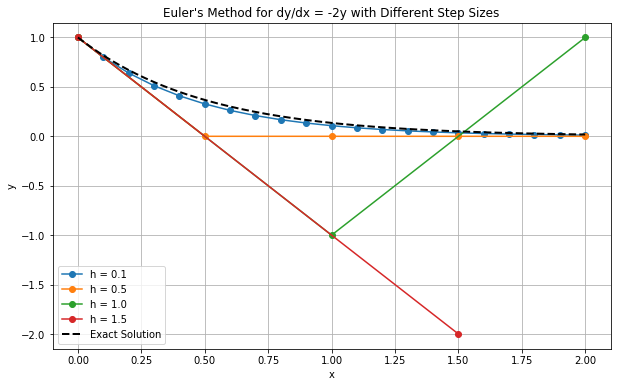

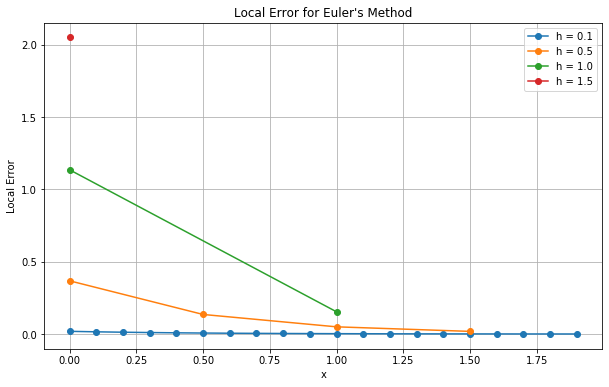

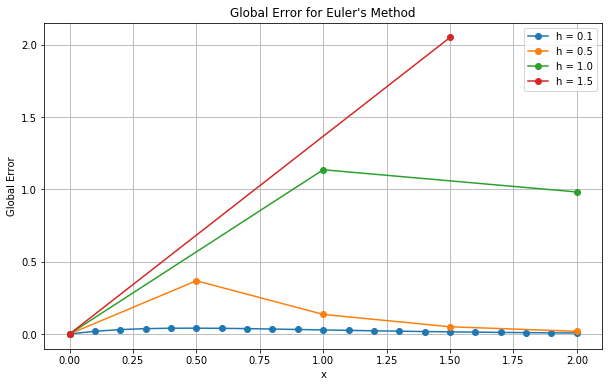

In [2]:
# Mrinal Pradhan
# Challenge 16
# Euler's Method

import numpy as np
import matplotlib.pyplot as plt

# Exact solution for comparison
def exact(x):
    return np.exp(-2 * x)

# Function representing dy/dx = -2y
def f(x, y):
    return -2 * y

# Local error function
def local_error(h, x_values):
    errors = []
    for i in range(len(x_values) - 1):
        x_n = x_values[i]
        y_exact_n = exact(x_n)

        # one Euler step starting from the exact value
        euler_step = y_exact_n + h * f(x_n, y_exact_n)

        # exact next value
        true_next = exact(x_n + h)

        errors.append(abs(true_next - euler_step))
    return np.array(errors)

# Global error function
def global_error(x_values, y_values):
    return np.abs(exact(x_values) - y_values)

# Define interval
x_start, x_end = 0, 2

# Step sizes required
step_sizes = [0.1, 0.5, 1.0, 1.5]

# Store first run so all later errors can be compared to it
first_run_interp = None

plt.figure(figsize=(10, 6))

for run_num, h in enumerate(step_sizes):
    num_steps = int((x_end - x_start) / h)

    x_values = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # Initial condition
    y_values[0] = 1  # y(0) = 1

    # Implement Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # Plot each run
    plt.plot(x_values, y_values, marker='o', label=f"h = {h:.1f}")

    # Error vs exact solution at each point
    exact_vals = exact(x_values)
    pointwise_error = np.abs(y_values - exact_vals)
    total_accumulated_error = np.sum(pointwise_error)

    # Local and global errors
    local_err = local_error(h, x_values)
    global_err = global_error(x_values, y_values)

    print(f"\nRun with step size h = {h:.1f}")
    print("x\t\tError(current run vs first run)")

    # Save first run
    if run_num == 0:
        first_run_x = x_values.copy()
        first_run_y = y_values.copy()
        first_run_interp = lambda x: np.interp(x, first_run_x, first_run_y)
        compare_error = np.zeros_like(x_values)
    else:
        first_vals_on_current_grid = first_run_interp(x_values)
        compare_error = np.abs(y_values - first_vals_on_current_grid)

    for x, err in zip(x_values, compare_error):
        print(f"{x:.2f}\t\t{err:.8f}")

    print("Local errors:", local_err)
    print("Global errors:", global_err)
    print(f"Total local error = {np.sum(local_err):.8f}")
    print(f"Total global error = {np.sum(global_err):.8f}")
    print(f"Total accumulated error vs exact solution = {total_accumulated_error:.8f}")

# Plot exact solution too
x_exact = np.linspace(x_start, x_end, 500)
plt.plot(x_exact, exact(x_exact), 'k--', linewidth=2, label="Exact Solution")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for dy/dx = -2y with Different Step Sizes")
plt.legend()
plt.grid(True)
plt.show()

# Plot local error
plt.figure(figsize=(10, 6))
for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    local_err = local_error(h, x_values)
    plt.plot(x_values[:-1], local_err, marker='o', label=f"h = {h:.1f}")

plt.xlabel("x")
plt.ylabel("Local Error")
plt.title("Local Error for Euler's Method")
plt.legend()
plt.grid(True)
plt.show()

# Plot global error
plt.figure(figsize=(10, 6))
for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    global_err = global_error(x_values, y_values)
    plt.plot(x_values, global_err, marker='o', label=f"h = {h:.1f}")

plt.xlabel("x")
plt.ylabel("Global Error")
plt.title("Global Error for Euler's Method")
plt.legend()
plt.grid(True)
plt.show()
# The larger the step size, the larger the local and global errors.